# Custom inference pipeline 만들기
- Stable diffusion에 필요한 모델들을 직접 불러오고, custom pipeline만들기
- 아래는 필요한 pre-trained model이다.
  - text_encoder
      - stable diffusion은 CLIP을 사용하지만, custom 가능
  - tokenizer
    - 모델에서 사용하는 것과 동일한 것을 사용해야함
  - scheduler
    - 훈련 중 이미지에 점진적으로 노이즈를 추가하는 데 사용되는 스케쥴러임
  - unet
    - latent representation을 만드는 모델
  - vae
    - 잠재 표현을 실제 이미지로 디코딩하는 데 사용할 autoencoder
   
참고 https://huggingface.co/blog/stable_diffusion

In [1]:
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, PNDMScheduler
from diffusers import LMSDiscreteScheduler
import torch

/home/qkboo/.pyenv/versions/3.12.1/envs/Goodyoung_P312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 위 model들 불러오기

In [2]:
# 1. Load the autoencoder model
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

vae.to('cuda')

# 2. Load the tokenizer and text encoder
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14")

text_encoder.to('cuda')

# 3. The UNet model 
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet")

unet.to('cuda')
scheduler = LMSDiscreteScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000)

### 기본 변수들

In [3]:
prompt = ["a photograph of an astronaut riding a horse"]
height = 512                        # default height of Stable Diffusion
width = 512                         # default width of Stable Diffusion
num_inference_steps = 100           # Number of denoising steps
guidance_scale = 7.5                # Scale for classifier-free guidance
generator = torch.manual_seed(0)    # Seed generator to create the inital latent noise
batch_size = len(prompt)

### prompt 변환
- tokenizer을 거쳐 token 단위로 분리
- 그 후 text encoder을 통과하여 text embedding 생성

In [4]:
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
text_embeddings = text_encoder(text_input.input_ids.to('cuda'))[0]

### Classifier-free guidance를 위한 작업

#### 📌 Classifier-Free Guidance (CFG)란?

**Classifier-Free Guidance (CFG)** 는 **이미지 생성 모델에서 노이즈를 조정하여 이미지 품질을 높이는 기법**입니다.  
- 일반적으로 **텍스트 조건(conditional)과 비조건(unconditional) 샘플링을 함께 사용**하여 모델이 텍스트 프롬프트에 더 강하게 반응하도록 유도한다.
- **Unconditional 샘플링**은 모델이 텍스트 없이도 노이즈를 예측할 수 있도록 합니다.
- **Conditional 샘플링**은 입력된 텍스트를 반영하여 노이즈를 조정합니다.

이를 활용하면 아래와 같은 방식으로 **생성 결과를 제어**할 수 있습니다:

$\tilde{\epsilon}_\theta(x_t, t, c) = \epsilon_\theta(x_t, t, \emptyset) + w \cdot (\epsilon_\theta(x_t, t, c) - \epsilon_\theta(x_t, t, \emptyset))$

- ($\epsilon_\theta(x_t, t, c)$): 텍스트 프롬프트(조건부)로부터 얻은 노이즈 예측.
- ($\epsilon_\theta(x_t, t, \emptyset)$): **텍스트 없이(unconditional)** 얻은 노이즈 예측.
- **CFG Scale (w)** 을 조절하면 텍스트 조건이 샘플링 과정에서 더 강하게 반영됩니다.

In [5]:
# CFG를 위하여 unconditional embedding을 만드는 과정
max_length = text_input.input_ids.shape[-1]
uncond_input = tokenizer(
    [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt" # 비어있는 prompt를 생성하여 uncondition 조건을 충족
)
uncond_embeddings = text_encoder(uncond_input.input_ids.to('cuda'))[0]

- 위 $\tilde{\epsilon}_\theta$식에 의하면 두 번의 forward pass가 필요하다.
- 하지만 token을 batch로 묶어줘서 한 번의 forward pass로 두 개의 출력을 동시에 계산할 수 있다.

In [6]:
print('기존 shape: ', uncond_embeddings.shape)
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])
print('바뀐 shape: ', text_embeddings.shape) # 배치가 증가한 것을 볼 수 있다

기존 shape:  torch.Size([1, 77, 768])
바뀐 shape:  torch.Size([2, 77, 768])


### latent 만들기
- `LDM-8`으로 생성
- 스케줄러가 필요로 하는 특정 노이즈 분포에 맞춰 조정하기 위해서, 초기 노이즈의 표준 편차 (sigma) 값을 곱하여 **초기 노이즈를 정규화한다.**
  - `K-LMS scheduler`에서 필요한대로 sigma를 곱해준다

In [7]:
latents = torch.randn(
    (batch_size, unet.config.in_channels, height // 8, width // 8), # 원본 이미지의 8배 downsampling
    generator=generator,
)
latents = latents.to('cuda')

In [8]:
latents = latents * scheduler.init_noise_sigma

### Denoising loop

In [9]:
from tqdm import tqdm  

# 샘플링 단계 수 설정
scheduler.set_timesteps(num_inference_steps)

# 스케줄러에서 정의한 타임스텝을 순회하면서 노이즈 제거 진행
for t in tqdm(scheduler.timesteps):  
    # CFG로 인한 latents확장
    latent_model_input = torch.cat([latents] * 2) 

    # 각 타임스텝에서 모델 입력을 스케줄러가 요구하는 형태로 변환 (일반적으로 스케일 조정)
    latent_model_input = scheduler.scale_model_input(latent_model_input, timestep=t)

    # U-Net을 사용하여 노이즈 예측 수행
    with torch.no_grad(): 
        noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

    # Classifier-Free Guidance 적용
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)  # 두 개의 예측 값을 나눔 (unconditional, conditional)
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)  

    # 노이즈 제거 과정 진행 (x_t -> x_t-1)
    latents = scheduler.step(noise_pred, t, latents).prev_sample  # 현재 노이즈 예측을 기반으로 latents 업데이트

100%|██████████| 100/100 [00:13<00:00,  7.37it/s]


### latent space -> original image decoding
- `VAE(Variational Autoencoder)`를 사용하여 `latents(잠재 공간의 데이터)`를 복원하고 이미지로 변환하는 과정

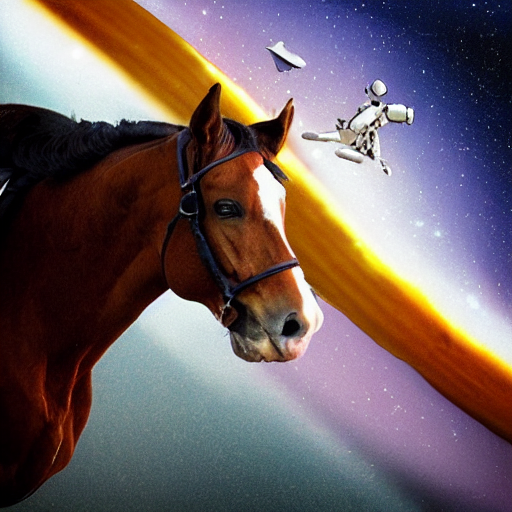

In [10]:
from PIL import Image
# latents를 VAE가 기대하는 크기로 스케일 조정
latents = 1 / 0.18215 * latents  # latents를 디코딩하기 전에 특정 값(0.18215)으로 나누어야 함.

# VAE를 사용하여 latents -> 실제 이미지 데이터
with torch.no_grad():  
    image = vae.decode(latents).sample  

# 이미지 값을 [0, 1] 범위로 정규화
image = (image / 2 + 0.5).clamp(0, 1)  
# Diffusion 모델이 출력하는 이미지는 [-1, 1] 범위를 가질 수 있으므로, (image / 2 + 0.5) 연산을 통해 [0, 1] 범위로 변환.
# `clamp(0,1)`를 사용하여 값이 0~1을 넘지 않도록 제한.

image = image.detach().cpu().permute(0, 2, 3, 1).numpy()   # (BCHW → BHWC)

images = (image * 255).round().astype("uint8")  #PIL에서 사용 가능하도록 데이터 타입을 8비트 정수(uint8)로 변환 
pil_images = [Image.fromarray(image) for image in images]  

pil_images[0]  